# AtomFlow Controller — Unified PYNQ Control

Combines image analysis (reconstruct) + atom sorting into the single
`atomflow_controller` IP running on the FPGA.

Two modes:
- **MODE_QUBIT_READOUT (0)**: image analysis only → read emissions
- **MODE_INITIALIZATION (1)**: image analysis + sorting → read emissions + moves from AXI-Stream FIFO

Test configuration matches `tb_atomflow_controller.cpp` exactly.

## 1. Imports and Overlay

In [28]:
from pynq import Overlay, allocate, MMIO
import numpy as np
import struct
import time
import matplotlib.pyplot as plt

print("Loading overlay...")
ol = Overlay("design_1.bit")
ol.download()
print("\u2713 Overlay loaded")
print("IP dict:", list(ol.ip_dict.keys()))

Loading overlay...
✓ Overlay loaded
IP dict: ['atomflow_controller_0', 'axi_fifo_mm_s_0', 'zynq_ultra_ps_e_0']


## 2. Register Map

Offsets from `xatomflow_controller_hw.h` (Vitis HLS 2024.2).
Scalars and m_axi address registers are **interleaved** — do not use old offset tables.

In [29]:
# ap_ctrl
CTRL            = 0x00
AP_START        = 1 << 0
AP_DONE         = 1 << 1
AP_IDLE         = 1 << 2
AP_READY        = 1 << 3

# Scalars and m_axi pointers (interleaved, from xatomflow_controller_hw.h)
MODE_OFFSET          = 0x10   # uint8_t  mode
THRESHOLD_OFFSET     = 0x18   # float    emission_threshold
ATOM_LOC_SIZE        = 0x20   # int      atomLocationsSize
PROJ_SHAPE0          = 0x28   # int      projShape0
PROJ_SHAPE1          = 0x30   # int      projShape1
ADDR_ATOM_LOC_LO     = 0x38   # m_axi atomLocations [31:0]
ADDR_ATOM_LOC_HI     = 0x3C   # m_axi atomLocations [63:32]
PSF_SUPER            = 0x44   # int      psfSupersample
IMG_PROJ_SIZE        = 0x4C   # int      imageProjectionSize
ADDR_PROJS_LOCAL_LO  = 0x54   # m_axi imageProjs_local [31:0]
ADDR_PROJS_LOCAL_HI  = 0x58
ADDR_IMAGE_PROJS_LO  = 0x60   # m_axi imageProjs [31:0]
ADDR_IMAGE_PROJS_HI  = 0x64
ADDR_PROJS_LOCAL_SZ_LO = 0x6C # m_axi imageProjs_local_size [31:0]
ADDR_PROJS_LOCAL_SZ_HI = 0x70
ADDR_FULL_IMAGE_LO   = 0x78   # m_axi fullImage [31:0]
ADDR_FULL_IMAGE_HI   = 0x7C
FULL_IMG_ROWS        = 0x84   # int      fullImage_rows
FULL_IMG_COLS        = 0x8C   # int      fullImage_cols
ADDR_EMISSIONS_LO    = 0x94   # m_axi emissions [31:0]
ADDR_EMISSIONS_HI    = 0x98
GRID_ROWS            = 0xA0   # int      grid_rows
GRID_COLS            = 0xA8   # int      grid_cols
ADDR_TARGET_GEO_LO   = 0xB0   # m_axi targetGeometry_mem [31:0]
ADDR_TARGET_GEO_HI   = 0xB4
COMP_ROW_START       = 0xBC   # uint     compZoneRowStart
COMP_ROW_END         = 0xC4   # uint     compZoneRowEnd
COMP_COL_START       = 0xCC   # uint     compZoneColStart
COMP_COL_END         = 0xD4   # uint     compZoneColEnd
MOVE_COUNT_REG       = 0xDC   # uint     moveCount (read-only)
STATUS_REG           = 0xEC   # uint     status         (read-only)
TARGETS_FILLED_REG   = 0xFC   # uint     targetsFilled  (read-only)
TARGETS_REQUIRED_REG = 0x10C  # uint     targetsRequired(read-only)

# ATOMFLOW_STATUS_* from atomflow_controller.hpp.
# 0 means the register was never written -> stale bitstream without these ports.
ATOMFLOW_STATUS = {
    0: "NOT-WRITTEN (old bitstream?)",
    1: "OK",
    2: "ERR_ZONE (grid/zone geometry invalid)",
    3: "ERR_ATOM_COUNT (atomLocationsSize != zone area)",
    4: "ERR_SORT (sorter failed or target not fully filled)",
    5: "ERR_IMAGE_CFG (image params outside the fixed 31x31 / PSF=1 config)",
    6: "ERR_ATOM_OOB (an atom's PSF window falls outside the image)",
    7: "ERR_MODE (unknown controller mode)",
    8: "ERR_NONFINITE (NaN/Inf threshold or atom coordinate)",
    9: "ERR_CAPACITY (planner or moving-list capacity exceeded)",
}
STATUS_OK = 1

# ParallelMove flag bits (sortLatticeByRow.hpp). Defined here, in the constants
# cell, so every decoder below works even when cells are re-run out of order.
MOVE_FLAG_DISCARD = 0x01

MODE_QUBIT_READOUT  = 0
MODE_INITIALIZATION = 1

# AXI4-Stream FIFO (axi_fifo_mm_s)
FIFO_RDFR = 0x18   # Receive FIFO Reset (write 0xA5)
FIFO_RDFO = 0x1C   # Receive FIFO Occupancy (word count)
FIFO_RDFD = 0x20   # Receive FIFO Data
FIFO_RLR  = 0x24   # Receive Length Register (byte count)

CTRL_BASE = ol.ip_dict["atomflow_controller_0"]["phys_addr"]
FIFO_BASE = ol.ip_dict["axi_fifo_mm_s_0"]["phys_addr"]

ctrl = MMIO(CTRL_BASE, 0x1000)
fifo = MMIO(FIFO_BASE, 0x1000)

print(f"atomflow_controller @ {hex(CTRL_BASE)}")
print(f"AXI-Stream FIFO     @ {hex(FIFO_BASE)}")
v = ctrl.read(CTRL)
print(f"AP_CTRL = 0x{v:08X}  (IDLE={bool(v & AP_IDLE)})")

# ── Fast FIFO data read ────────────────────────────────────────────────────
# RDFD is a streaming port: every read pops one word, so N words means N reads
# of the SAME address. PYNQ's MMIO.read() costs ~7.60 us per call (measured on
# this board, N=20000); the numpy view it wraps costs ~1.75 us. Going through
# the view removes the Python method-call and bounds-check overhead without
# changing semantics -- it is still one hardware read per word, same address.
# Falls back to MMIO.read() if this PYNQ version does not expose .array.
try:
    _FIFO_ARR = fifo.array
    _RDFD_IDX = FIFO_RDFD // 4
    _FAST_FIFO = True
    def fifo_read_words(n):
        """Pop n 32-bit words from the FIFO, return them as little-endian bytes."""
        a, i = _FIFO_ARR, _RDFD_IDX
        return np.asarray([a[i] for _ in range(n)], dtype="<u4").tobytes()
except AttributeError:
    _FAST_FIFO = False
    def fifo_read_words(n):
        return b"".join(struct.pack("<I", fifo.read(FIFO_RDFD)) for _ in range(n))
print(f"FIFO fast read: {'numpy view (~1.75 us/word)' if _FAST_FIFO else 'MMIO.read fallback (~7.6 us/word)'}")


atomflow_controller @ 0xa0000000
AXI-Stream FIFO     @ 0xa0010000
AP_CTRL = 0x00000004  (IDLE=True)


## 3. Helper Functions

In [30]:
def write_addr64(mmio, lo_off, hi_off, addr):
    addr = int(addr)
    mmio.write(lo_off, addr & 0xFFFFFFFF)
    mmio.write(hi_off, (addr >> 32) & 0xFFFFFFFF)

def write_float(mmio, offset, val):
    bits = struct.unpack("<I", struct.pack("<f", float(val)))[0]
    mmio.write(offset, bits)

def atomflow_run(mode, emission_threshold,
                 atom_loc_size, proj_shape0, proj_shape1,
                 psf_supersample, img_proj_size,
                 full_img_rows, full_img_cols,
                 grid_rows, grid_cols,
                 comp_row_start, comp_row_end, comp_col_start, comp_col_end,
                 atomLocations_buf, imageProjs_buf, imageProjs_local_buf,
                 imageProjs_local_size_buf, fullImage_buf,
                 emissions_buf, targetGeometry_buf,
                 timeout_s=30.0):
    """Run atomflow_controller.

    Returns (ms, move_count, status, targets_filled, targets_required).
    Raises on a configuration error, which cannot produce a usable result.
    """
    # Write in hw.h address order (scalars and m_axi pointers interleaved)
    ctrl.write(MODE_OFFSET,    mode)
    write_float(ctrl, THRESHOLD_OFFSET, emission_threshold)
    ctrl.write(ATOM_LOC_SIZE,  atom_loc_size)
    ctrl.write(PROJ_SHAPE0,    proj_shape0)
    ctrl.write(PROJ_SHAPE1,    proj_shape1)
    write_addr64(ctrl, ADDR_ATOM_LOC_LO,       ADDR_ATOM_LOC_HI,       atomLocations_buf.physical_address)
    ctrl.write(PSF_SUPER,      psf_supersample)
    ctrl.write(IMG_PROJ_SIZE,  img_proj_size)
    write_addr64(ctrl, ADDR_PROJS_LOCAL_LO,    ADDR_PROJS_LOCAL_HI,    imageProjs_local_buf.physical_address)
    write_addr64(ctrl, ADDR_IMAGE_PROJS_LO,    ADDR_IMAGE_PROJS_HI,    imageProjs_buf.physical_address)
    write_addr64(ctrl, ADDR_PROJS_LOCAL_SZ_LO, ADDR_PROJS_LOCAL_SZ_HI, imageProjs_local_size_buf.physical_address)
    write_addr64(ctrl, ADDR_FULL_IMAGE_LO,     ADDR_FULL_IMAGE_HI,     fullImage_buf.physical_address)
    ctrl.write(FULL_IMG_ROWS,  full_img_rows)
    ctrl.write(FULL_IMG_COLS,  full_img_cols)
    write_addr64(ctrl, ADDR_EMISSIONS_LO,      ADDR_EMISSIONS_HI,      emissions_buf.physical_address)
    ctrl.write(GRID_ROWS,      grid_rows)
    ctrl.write(GRID_COLS,      grid_cols)
    write_addr64(ctrl, ADDR_TARGET_GEO_LO,     ADDR_TARGET_GEO_HI,     targetGeometry_buf.physical_address)
    ctrl.write(COMP_ROW_START, comp_row_start)
    ctrl.write(COMP_ROW_END,   comp_row_end)
    ctrl.write(COMP_COL_START, comp_col_start)
    ctrl.write(COMP_COL_END,   comp_col_end)

    # Quick sanity check
    rb_mode = ctrl.read(MODE_OFFSET) & 0xFF
    rb_zrs  = ctrl.read(COMP_ROW_START)
    rb_zre  = ctrl.read(COMP_ROW_END)
    print(f"  [check] mode={rb_mode} compZoneRows=[{rb_zrs},{rb_zre})")
    if rb_mode != mode or rb_zrs != comp_row_start or rb_zre != comp_row_end:
        print("  WARNING: register readback mismatch!")

    for _ in range(10000):
        if ctrl.read(CTRL) & AP_IDLE:
            break
        time.sleep(0.001)
    else:
        raise TimeoutError("IP never went IDLE")

    t0 = time.perf_counter()
    ctrl.write(CTRL, AP_START)

    while True:
        if ctrl.read(CTRL) & AP_DONE:
            break
        if time.perf_counter() - t0 > timeout_s:
            raise TimeoutError(f"Timeout after {timeout_s}s")
        time.sleep(0.001)

    elapsed_ms = (time.perf_counter() - t0) * 1e3
    move_count = ctrl.read(MOVE_COUNT_REG)
    status     = ctrl.read(STATUS_REG)
    t_filled   = ctrl.read(TARGETS_FILLED_REG)
    t_required = ctrl.read(TARGETS_REQUIRED_REG)

    # status tells the PS whether moveCount and the move stream can be trusted;
    # targets say whether the requested geometry was actually achieved.
    print(f"  [status] {status} ({ATOMFLOW_STATUS.get(status, 'UNKNOWN')})"
          f"  targets={t_filled}/{t_required}")
    if status not in (STATUS_OK, 4):
        raise RuntimeError(f"controller rejected the run: "
                           f"{ATOMFLOW_STATUS.get(status, status)}")
    return elapsed_ms, move_count, status, t_filled, t_required

## 4. Allocate Memory Buffers

Sizes from HLS header (image_analysis.hpp):
- `IMAGE_PROJECTION_LOCAL = 1000`  (floats per atom in local proj buffer)
- `IMAGE_PROJECTION_SIZE  = 100`   (max atoms)
- `FULL_IMAGE_SIZE = 1024×1024`

In [31]:
# HLS constants (from atomflow_controller.hpp / image_analysis.hpp)
MAX_ATOM_SITES   = 2000         # MAX_ATOM_SITES in atomflow_controller.hpp
IMAGE_PROJ_SIZE  = 100          # IMAGE_PROJECTION_SIZE (max projections)
IMAGE_PROJ_LOCAL = 1000         # IMAGE_PROJECTION_LOCAL (floats per atom in local buf)
FULL_IMAGE_SIZE  = 1024 * 1024  # PIXEL * PIXEL

# atomLocations and emissions: indexed by atom site (up to 2000)
# imageProjs*: indexed by projection (up to 100)
atomLocations_buf         = allocate(shape=(MAX_ATOM_SITES * 2,),               dtype=np.float32)
imageProjs_buf            = allocate(shape=(IMAGE_PROJ_SIZE,),                  dtype=np.float32)
imageProjs_local_buf      = allocate(shape=(IMAGE_PROJ_LOCAL * IMAGE_PROJ_SIZE,), dtype=np.float32)
imageProjs_local_size_buf = allocate(shape=(IMAGE_PROJ_SIZE,),                  dtype=np.int32)
fullImage_buf             = allocate(shape=(FULL_IMAGE_SIZE,),                  dtype=np.float32)
emissions_buf             = allocate(shape=(MAX_ATOM_SITES,),                   dtype=np.float32)
targetGeometry_buf        = allocate(shape=(64 * 64,),                          dtype=np.uint8)

print(f"atomLocations_buf         @ {hex(atomLocations_buf.physical_address)}")
print(f"imageProjs_buf            @ {hex(imageProjs_buf.physical_address)}")
print(f"imageProjs_local_buf      @ {hex(imageProjs_local_buf.physical_address)}")
print(f"imageProjs_local_size_buf @ {hex(imageProjs_local_size_buf.physical_address)}")
print(f"fullImage_buf             @ {hex(fullImage_buf.physical_address)}")
print(f"emissions_buf             @ {hex(emissions_buf.physical_address)}")
print(f"targetGeometry_buf        @ {hex(targetGeometry_buf.physical_address)}")

atomLocations_buf         @ 0x77cfc000
imageProjs_buf            @ 0x265f1000
imageProjs_local_buf      @ 0x7a580000
imageProjs_local_size_buf @ 0x68ec3000
fullImage_buf             @ 0x7b700000
emissions_buf             @ 0x77cfa000
targetGeometry_buf        @ 0x68ec0000


## 5. Load Input Data

Uses the same test files as `tb_atomflow_controller.cpp`:
- `restoutput.txt` (atom locations, projections)
- `fullImage_output.txt` (camera image)

`input_read.py` matches testbench parsing exactly:
- atom_location struct = `{float x; float y;}` → file order is y first, x second
- fullImage re-strided to PIXEL=1024 column layout before packing

In [32]:
import sys, os
sys.path.insert(0, ".")
from input_read import parse_input_file, parse_fullImage, pack_floats_to_512bit, pack_fullimage_512bit, IMAGE_PROJECTION_LOCAL

# ---- adjust paths to where files are on the board ----
INPUT_FILE    = "restoutput.txt"
FULL_IMG_FILE = "fullImage_output.txt"
# -------------------------------------------------------

t0 = time.time()
input_data, _     = parse_input_file(INPUT_FILE)
full_image_raw, _ = parse_fullImage(FULL_IMG_FILE)
print(f"Parsed in {time.time()-t0:.3f}s")

atom_count  = input_data["atomLocationsSize"]
proj_shape0 = input_data["projShape0"]
proj_shape1 = input_data["projShape1"]
psf_super   = input_data["psfSupersample"]
img_proj_sz = input_data["imageProjectionSize"]
full_rows   = input_data["fullImage_rows"]
full_cols   = input_data["fullImage_cols"]

print(f"  atom_count  : {atom_count}")
print(f"  img_proj_sz : {img_proj_sz}")
print(f"  proj_shape  : {proj_shape0} x {proj_shape1}")
print(f"  full_image  : {full_rows} x {full_cols}")
assert atom_count  <= MAX_ATOM_SITES,  f"atom_count {atom_count} > MAX_ATOM_SITES {MAX_ATOM_SITES}"
assert img_proj_sz <= IMAGE_PROJ_SIZE, f"img_proj_sz {img_proj_sz} > IMAGE_PROJ_SIZE {IMAGE_PROJ_SIZE}"

# Atom locations: struct {float x; float y;}, testbench: y=parts[0], x=parts[1]
atomLocations_buf[:] = 0.0
for i, (x, y) in enumerate(input_data["atomLocations"][:atom_count]):
    atomLocations_buf[2*i]   = np.float32(x)
    atomLocations_buf[2*i+1] = np.float32(y)

# imageProjs (one float per projection, up to IMAGE_PROJ_SIZE)
n_projs = min(img_proj_sz, IMAGE_PROJ_SIZE)
imageProjs_buf[:n_projs] = np.array(input_data["imageProjs"][:n_projs], dtype=np.float32)

# imageProjs_local (stride IMAGE_PROJECTION_LOCAL=1000 per projection)
local_flat = np.array(input_data["imageProjs_local"], dtype=np.float32)
n_local = min(len(local_flat), IMAGE_PROJ_LOCAL * IMAGE_PROJ_SIZE)
imageProjs_local_buf[:n_local] = local_flat[:n_local]

# imageProjs_local_size
local_sizes = input_data.get("imageProjs_local_size", [])
if not local_sizes:
    local_sizes = [proj_shape0 * proj_shape1] * n_projs
imageProjs_local_size_buf[:n_projs] = np.array(local_sizes[:n_projs], dtype=np.int32)

# Re-stride to PIXEL=1024 column layout (testbench: fullImg_strided[r*PIXEL+c] = fullImg[r*fcols+c])
full_image_strided = pack_fullimage_512bit(full_image_raw, full_rows, full_cols)
fullImage_buf[:FULL_IMAGE_SIZE] = full_image_strided[:FULL_IMAGE_SIZE]

for buf in [atomLocations_buf, imageProjs_buf, imageProjs_local_buf,
            imageProjs_local_size_buf, fullImage_buf]:
    buf.flush()
print("\u2713 Buffers loaded and flushed")

Parsed in 0.371s
  atom_count  : 256
  img_proj_sz : 1
  proj_shape  : 31 x 31
  full_image  : 400 x 400
✓ Buffers loaded and flushed


In [33]:
# --- Debug: verify buffer contents after loading ---
print(f"full_image_raw   : {len(full_image_raw)} values, first={full_image_raw[:3]}")
print(f"fullImage_buf    : max={np.max(fullImage_buf):.1f}  nonzero={np.count_nonzero(fullImage_buf)}")
print(f"imageProjs_buf   : max={np.max(imageProjs_buf[:n_projs]):.1f}  n_projs={n_projs}")
print(f"imageProjs_local : max={np.max(imageProjs_local_buf):.1f}  nonzero={np.count_nonzero(imageProjs_local_buf)}")
print(f"atomLoc[0]       : x={atomLocations_buf[0]:.2f}  y={atomLocations_buf[1]:.2f}")
print(f"img_proj_sz={img_proj_sz}, atom_count={atom_count}, full_rows={full_rows}, full_cols={full_cols}")

full_image_raw   : 160000 values, first=[202.0, 205.0, 199.0]
fullImage_buf    : max=304.0  nonzero=160000
imageProjs_buf   : max=158.4  n_projs=1
imageProjs_local : max=2.9  nonzero=361
atomLoc[0]       : x=50.52  y=350.04
img_proj_sz=1, atom_count=256, full_rows=400, full_cols=400


## 6. Configure Grid and Target Geometry

In [34]:
# Physical trap grid. The sorter needs empty columns OUTSIDE the computation
# zone to park atoms during rearrangement; without them the target cannot be
# filled (16x16 with no parking reaches only 89/96).
GRID_R, GRID_C = 16, 32

# Image detection covers ONLY the central computation zone.
DETECT_R, DETECT_C = 16, 16
COMP_R0, COMP_R1 = 0, DETECT_R
COMP_C0 = (GRID_C - DETECT_C) // 2      # 8  -> cols 0-7 are parking
COMP_C1 = COMP_C0 + DETECT_C            # 24 -> cols 24-31 are parking
ZONE_R, ZONE_C = COMP_R1 - COMP_R0, COMP_C1 - COMP_C0

def make_target(rows, cols):
    """Testbench target pattern:
    rows r%4==0 or r%4==1: cols 1..(cols//2-2) and (cols//2+1)..(cols-2) filled.
    For 16 cols: cols 1-6 and 9-14 are filled."""
    tgt = np.zeros(rows * cols, dtype=np.uint8)
    half = cols // 2
    for r in range(rows):
        if r % 4 == 0 or r % 4 == 1:
            for c in range(cols):
                if (1 <= c <= half - 2) or (half + 1 <= c <= cols - 2):
                    tgt[r * cols + c] = 1
    return tgt

# targetGeometry is ZONE-LOCAL (16x16), not full-grid: load_target_geometry()
# reads exactly (compZoneRowEnd-Start) x (compZoneColEnd-Start) bytes.
target_flat = make_target(ZONE_R, ZONE_C)
target_2d   = target_flat.reshape(ZONE_R, ZONE_C)

targetGeometry_buf[:] = 0
np.copyto(targetGeometry_buf[:ZONE_R * ZONE_C], target_flat)
targetGeometry_buf.flush()

print(f"Physical grid: {GRID_R}x{GRID_C}   detection/zone: {ZONE_R}x{ZONE_C}")
print(f"Comp zone: rows [{COMP_R0},{COMP_R1}) x cols [{COMP_C0},{COMP_C1})"
      f"   parking cols: 0-{COMP_C0-1} and {COMP_C1}-{GRID_C-1}")
print(f"Target: {np.sum(target_flat)} sites (zone-local {ZONE_R}x{ZONE_C})")
print("Target pattern (zone):")
for r in range(ZONE_R):
    print("  " + "".join("X" if target_2d[r, c] else "." for c in range(ZONE_C)))


Target: 96 sites in 16x16 grid
Comp zone: rows [0,16) x cols [0,16)
Target pattern:
  .XXXXXX..XXXXXX.
  .XXXXXX..XXXXXX.
  ................
  ................
  .XXXXXX..XXXXXX.
  .XXXXXX..XXXXXX.
  ................
  ................
  .XXXXXX..XXXXXX.
  .XXXXXX..XXXXXX.
  ................
  ................
  .XXXXXX..XXXXXX.
  .XXXXXX..XXXXXX.
  ................
  ................


## 7a. Run — MODE_QUBIT_READOUT

Runs image analysis only → compute emissions, derive adaptive threshold.

In [35]:
print("Running MODE_QUBIT_READOUT...")
elapsed_ms, move_count, status, t_filled, t_required = atomflow_run(
    mode=MODE_QUBIT_READOUT,
    emission_threshold=0.0,
    atom_loc_size=atom_count,
    proj_shape0=proj_shape0, proj_shape1=proj_shape1,
    psf_supersample=psf_super, img_proj_size=img_proj_sz,
    full_img_rows=full_rows, full_img_cols=full_cols,
    grid_rows=GRID_R, grid_cols=GRID_C,
    comp_row_start=COMP_R0, comp_row_end=COMP_R1,
    comp_col_start=COMP_C0, comp_col_end=COMP_C1,
    atomLocations_buf=atomLocations_buf, imageProjs_buf=imageProjs_buf,
    imageProjs_local_buf=imageProjs_local_buf,
    imageProjs_local_size_buf=imageProjs_local_size_buf,
    fullImage_buf=fullImage_buf, emissions_buf=emissions_buf,
    targetGeometry_buf=targetGeometry_buf,
)
print(f"\u2713 {elapsed_ms:.1f} ms | moveCount={move_count} (expected 0)")

emissions_buf.invalidate()
emissions = np.copy(emissions_buf[:atom_count])

emin = float(np.min(emissions[emissions > 0])) if np.any(emissions > 0) else 0.0
emax = float(np.max(emissions))
EMISSION_THRESHOLD = (emax + emin) / 2.0   # adaptive, same as testbench

print(f"Emission range: [{emin:.1f}, {emax:.1f}]")
print(f"Adaptive threshold: {EMISSION_THRESHOLD:.1f}")

# Detections are zone-local; embed them into the physical grid so that the
# parking columns start empty, exactly as the controller does internally.
occupied      = (emissions > EMISSION_THRESHOLD)
occupied_zone = occupied.reshape(ZONE_R, ZONE_C)
state_grid    = np.zeros((GRID_R, GRID_C), dtype=bool)
state_grid[COMP_R0:COMP_R1, COMP_C0:COMP_C1] = occupied_zone

print(f"Occupied: {np.sum(occupied)}/{atom_count}  ({100*np.mean(occupied):.1f}%)")
print("Occupancy map (X=occupied, | marks the zone):")
for r in range(GRID_R):
    row = "".join("X" if state_grid[r, c] else "." for c in range(GRID_C))
    print(f"  {row[:COMP_C0]}|{row[COMP_C0:COMP_C1]}|{row[COMP_C1:]}")

Running MODE_QUBIT_READOUT...
  [check] mode=0 compZoneRows=[0,16)
✓ 2.9 ms | moveCount=0 (expected 0)
Emission range: [31610.1, 33824.0]
Adaptive threshold: 32717.1
Occupied: 125/256  (48.8%)
Occupancy map (X=occupied):
  ...X.XXX.X.X.X..
  .XX.XX.XX...XX..
  .X..X....XX...XX
  XX.XXXX...X.XX..
  .X..X...X..X..X.
  ...........X.XXX
  XXX.XXX.XX.X.X.X
  X.X..X....XX.XX.
  XXXXX.X..XX.XXXX
  X.X.XXXX..XXX.XX
  XX..XX....X.X.X.
  XX..XX.X....XX..
  ......XXXX.X.X..
  .XX.X..XXX.X..X.
  X...X.XX.XX.X...
  XX..XXX..X.XXXX.


## 7b. Run — MODE_INITIALIZATION

Runs image analysis + sorting. Moves streamed to AXI-Stream FIFO.

In [36]:
# Reset FIFO and drain any stale data before run
fifo.write(FIFO_RDFR, 0xA5)
time.sleep(0.1)  # wait for reset to complete
while fifo.read(FIFO_RDFO) > 0:
    pkt_bytes = fifo.read(FIFO_RLR)
    words = (pkt_bytes + 3) // 4
    fifo_read_words(words)   # discard
print("FIFO reset and drained")

print("Running MODE_INITIALIZATION (draining FIFO concurrently)...")

# Write all registers
ctrl.write(MODE_OFFSET, MODE_INITIALIZATION)
write_float(ctrl, THRESHOLD_OFFSET, EMISSION_THRESHOLD)
ctrl.write(ATOM_LOC_SIZE, atom_count); ctrl.write(PROJ_SHAPE0, proj_shape0); ctrl.write(PROJ_SHAPE1, proj_shape1)
write_addr64(ctrl, ADDR_ATOM_LOC_LO, ADDR_ATOM_LOC_HI, atomLocations_buf.physical_address)
ctrl.write(PSF_SUPER, psf_super); ctrl.write(IMG_PROJ_SIZE, img_proj_sz)
write_addr64(ctrl, ADDR_PROJS_LOCAL_LO, ADDR_PROJS_LOCAL_HI, imageProjs_local_buf.physical_address)
write_addr64(ctrl, ADDR_IMAGE_PROJS_LO, ADDR_IMAGE_PROJS_HI, imageProjs_buf.physical_address)
write_addr64(ctrl, ADDR_PROJS_LOCAL_SZ_LO, ADDR_PROJS_LOCAL_SZ_HI, imageProjs_local_size_buf.physical_address)
write_addr64(ctrl, ADDR_FULL_IMAGE_LO, ADDR_FULL_IMAGE_HI, fullImage_buf.physical_address)
ctrl.write(FULL_IMG_ROWS, full_rows); ctrl.write(FULL_IMG_COLS, full_cols)
write_addr64(ctrl, ADDR_EMISSIONS_LO, ADDR_EMISSIONS_HI, emissions_buf.physical_address)
ctrl.write(GRID_ROWS, GRID_R); ctrl.write(GRID_COLS, GRID_C)
write_addr64(ctrl, ADDR_TARGET_GEO_LO, ADDR_TARGET_GEO_HI, targetGeometry_buf.physical_address)
ctrl.write(COMP_ROW_START, COMP_R0); ctrl.write(COMP_ROW_END, COMP_R1)
ctrl.write(COMP_COL_START, COMP_C0); ctrl.write(COMP_COL_END, COMP_C1)

rb_mode = ctrl.read(MODE_OFFSET) & 0xFF
rb_zrs  = ctrl.read(COMP_ROW_START)
rb_zre  = ctrl.read(COMP_ROW_END)
print(f"  [check] mode={rb_mode} compZoneRows=[{rb_zrs},{rb_zre})")

# Wait IDLE
for _ in range(10000):
    if ctrl.read(CTRL) & AP_IDLE:
        break
    time.sleep(0.001)

# Start IP
t0 = time.perf_counter()
ctrl.write(CTRL, AP_START)

# Drain FIFO while IP runs, then after AP_DONE read until move_count packets received
all_raw_moves = []
t_first_move = None
ip_done = False

while True:
    # Drain all currently available packets
    while fifo.read(FIFO_RDFO) > 0:
        pkt_bytes = fifo.read(FIFO_RLR)
        words = (pkt_bytes + 3) // 4
        raw = bytearray(fifo_read_words(words))
        all_raw_moves.append(bytes(raw))
        if t_first_move is None:
            t_first_move = time.perf_counter()
            print(f"  First move at {(t_first_move - t0)*1e3:.1f} ms")

    if not ip_done and (ctrl.read(CTRL) & AP_DONE):
        ip_done = True
        move_count = ctrl.read(MOVE_COUNT_REG)
        status     = ctrl.read(STATUS_REG)
        t_filled   = ctrl.read(TARGETS_FILLED_REG)
        t_required = ctrl.read(TARGETS_REQUIRED_REG)
        if status != STATUS_OK:
            print(f"  WARNING status={status} ({ATOMFLOW_STATUS.get(status, chr(63))}) targets={t_filled}/{t_required}")
        print(f"  AP_DONE at {(time.perf_counter()-t0)*1e3:.1f} ms | expected {move_count} moves")

    # Once IP is done, keep reading until we have all move_count packets
    if ip_done and len(all_raw_moves) >= move_count:
        break

    if time.perf_counter() - t0 > 60.0:
        print("Timeout!")
        break
    time.sleep(0.0001)

elapsed_ms = (time.perf_counter() - t0) * 1e3
print(f"✓ {elapsed_ms:.1f} ms | moveCount={move_count} | FIFO packets read={len(all_raw_moves)}")

FIFO reset and drained
Running MODE_INITIALIZATION (draining FIFO concurrently)...
  [check] mode=1 compZoneRows=[0,16)
  First move at 3.4 ms
  AP_DONE at 26.7 ms | expected 29 moves
✓ 27.1 ms | moveCount=29 | FIFO packets read=29


## 8. Read Emissions

Occupied: 125/256  (48.8%)


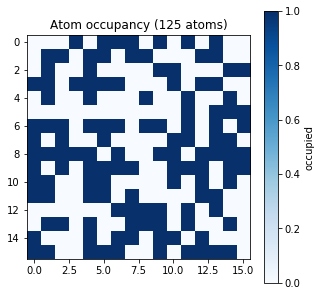

In [10]:
emissions_buf.invalidate()
emissions  = np.copy(emissions_buf[:atom_count])
occupied      = (emissions > EMISSION_THRESHOLD)
occupied_zone = occupied.reshape(ZONE_R, ZONE_C)
state_grid    = np.zeros((GRID_R, GRID_C), dtype=bool)
state_grid[COMP_R0:COMP_R1, COMP_C0:COMP_C1] = occupied_zone
print(f"Occupied: {np.sum(occupied)}/{atom_count}  ({100*np.mean(occupied):.1f}%)")

plt.figure(figsize=(5, 5))
plt.imshow(state_grid.astype(int), cmap="Blues", origin="upper")
plt.title(f"Atom occupancy ({np.sum(occupied)} atoms)")
plt.colorbar(label="occupied")
plt.savefig("occupancy.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Read Moves from AXI-Stream FIFO

`ParallelMove` layout (must match `sortLatticeByRow.hpp`):
- `Step`: `colSelection[16]` int16 (32B) + `rowSelection[16]` int16 (32B) + counts (2B) = **66B**
- `ParallelMove`: `steps[4]` (264B) + `stepsCount` uint8 = 265B → padded to **266B**
- Stream beats: ceil(266/64) = **5 beats** = 320B per move

In [37]:
MAX_STEPS      = 4    # MAX_MOVE_STEPS in hardware
MAX_SEL        = 16
STEP_SIZE      = 66                           # sizeof(Step)
MOVE_WIRE_SIZE = 320                          # 5 beats × 64B = 1 move (tlast=5)
STEPS_COUNT_OFF = MAX_STEPS * STEP_SIZE       # 264: offset of stepsCount
FLAGS_OFF       = STEPS_COUNT_OFF + 1         # 265: per-move flags byte

# MOVE_FLAG_DISCARD is defined in the register/constants cell above. It means
# at least one tone of this move ends outside the trap array, so the atoms it
# carries leave the system; the host used to infer that from the coordinates.

def decode_move(raw_move):
    """Decode one ParallelMove from a 320B packet (one complete FIFO packet)."""
    if len(raw_move) < MAX_STEPS * STEP_SIZE + 1:
        return None
    steps_count = raw_move[STEPS_COUNT_OFF]
    if steps_count == 0 or steps_count > MAX_STEPS:
        return None
    flags = raw_move[FLAGS_OFF] if len(raw_move) > FLAGS_OFF else 0
    steps = []
    for s in range(steps_count):
        off = s * STEP_SIZE
        cols_sel = list(struct.unpack_from(f"<{MAX_SEL}h", raw_move, off))
        rows_sel = list(struct.unpack_from(f"<{MAX_SEL}h", raw_move, off + 32))
        n_cols = raw_move[off + 64]
        n_rows = raw_move[off + 65]
        steps.append({"cols": cols_sel[:n_cols], "rows": rows_sel[:n_rows],
                      "flags": flags, "discard": bool(flags & MOVE_FLAG_DISCARD)})
    return steps

# With tlast=5, each FIFO packet is exactly one 320B move — decode per packet.
print(f"Packets received : {len(all_raw_moves)}")
print(f"Expected ({move_count} moves)")

all_moves = []
for i, pkt in enumerate(all_raw_moves[:move_count]):
    if len(pkt) != MOVE_WIRE_SIZE:
        print(f"  WARNING: packet {i} has {len(pkt)}B, expected {MOVE_WIRE_SIZE}B")
    move = decode_move(pkt)
    if move is None:
        sc = pkt[STEPS_COUNT_OFF] if len(pkt) > STEPS_COUNT_OFF else -1
        print(f"  Decode failed at packet {i} (stepsCount byte={sc})")
    else:
        all_moves.append(move)

print(f"✓ Decoded {len(all_moves)}/{move_count} moves")
if all_moves:
    spm = [len(m) for m in all_moves]
    print(f"  Steps/move: min={min(spm)}, max={max(spm)}, avg={np.mean(spm):.1f}")
    n_discard = sum(1 for m in all_moves if m[0]["discard"])
    print(f"  Discard moves (MOVE_FLAG_DISCARD): {n_discard}/{len(all_moves)}")
    n_empty = sum(1 for m in all_moves for st in m if not st["cols"] or not st["rows"])
    print(f"  Steps with an empty selection: {n_empty}  (expected 0 -- the sorter"
          f" no longer emits no-op moves)")
    for i, m in enumerate(all_moves[:5]):
        tag = " [discard]" if m[0]["discard"] else ""
        print(f"  Move {i}: {len(m)} steps{tag} | rows={m[0]['rows'][:4]}→{m[-1]['rows'][:4]}")

Packets received : 29
Expected (29 moves)
✓ Decoded 29/29 moves
  Steps/move: min=2, max=4, avg=3.8
  Move 0: 2 steps | rows=[0]→[-1]
  Move 1: 2 steps | rows=[1]→[-1]
  Move 2: 4 steps | rows=[2]→[0]
  Move 3: 4 steps | rows=[3]→[0]
  Move 4: 4 steps | rows=[3]→[1]


✓ Saved movelist to movelist_dump.txt


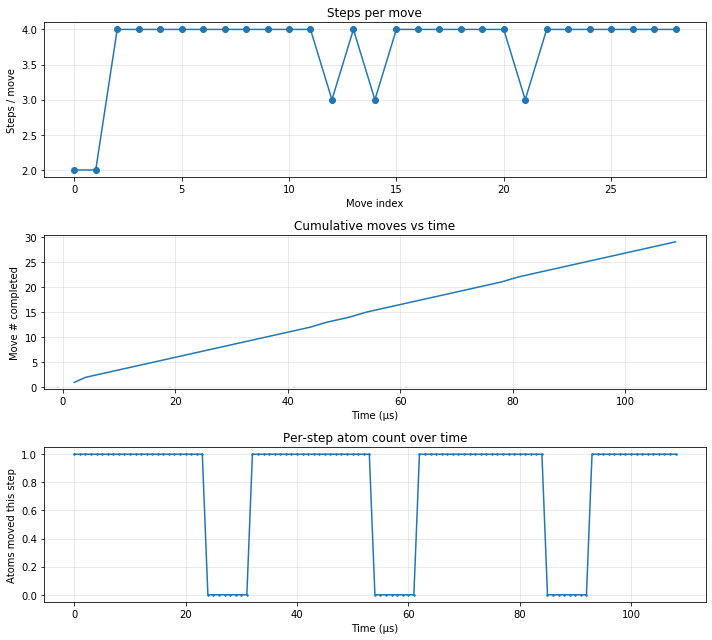

✓ Total steps=109, total time≈109.0 µs


In [38]:
import matplotlib.pyplot as plt
import numpy as np

# ---- 1) Save all moves + per-step timing to a txt file ----
TIME_PER_STEP_US = 1.0   # 修改成你硬件上每步的实际时间 (微秒)，或传入 step_times 数组

out_path = "movelist_dump.txt"
with open(out_path, "w") as f:
    f.write(f"# total_moves={len(all_moves)}\n")
    f.write(f"# format: move_idx step_idx t_us n_cols n_rows cols rows\n")
    t_us = 0.0
    for mi, move in enumerate(all_moves):
        for si, step in enumerate(move):
            cols = step["cols"]
            rows = step["rows"]
            f.write(
                f"{mi}\t{si}\t{t_us:.3f}\t{len(cols)}\t{len(rows)}\t"
                f"{cols}\t{rows}\n"
            )
            t_us += TIME_PER_STEP_US
print(f"✓ Saved movelist to {out_path}")

# ---- 2) Plot: steps-per-move, cumulative steps, atoms moved per step ----
steps_per_move = np.array([len(m) for m in all_moves])
cum_steps      = np.cumsum(steps_per_move)
move_time_us   = cum_steps * TIME_PER_STEP_US      # 每个 move 结束的累计时间

# 每一步移动的原子数 (= 该 step 内 cols/rows 的最小值，因为是配对移动)
atoms_per_step = []
step_time_axis = []
t = 0.0
for move in all_moves:
    for step in move:
        atoms_per_step.append(min(len(step["cols"]), len(step["rows"])))
        step_time_axis.append(t)
        t += TIME_PER_STEP_US
atoms_per_step = np.array(atoms_per_step)
step_time_axis = np.array(step_time_axis)

fig, ax = plt.subplots(3, 1, figsize=(10, 9), sharex=False)

ax[0].plot(np.arange(len(all_moves)), steps_per_move, "o-")
ax[0].set_xlabel("Move index")
ax[0].set_ylabel("Steps / move")
ax[0].set_title("Steps per move")
ax[0].grid(True, alpha=0.3)

ax[1].plot(move_time_us, np.arange(1, len(all_moves) + 1), "-")
ax[1].set_xlabel("Time (µs)")
ax[1].set_ylabel("Move # completed")
ax[1].set_title("Cumulative moves vs time")
ax[1].grid(True, alpha=0.3)

ax[2].plot(step_time_axis, atoms_per_step, ".-", markersize=3)
ax[2].set_xlabel("Time (µs)")
ax[2].set_ylabel("Atoms moved this step")
ax[2].set_title("Per-step atom count over time")
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("movelist_timeline.png", dpi=150)
plt.show()
print(f"✓ Total steps={cum_steps[-1]}, total time≈{move_time_us[-1]:.1f} µs")


## 10. Visualize Sorted State

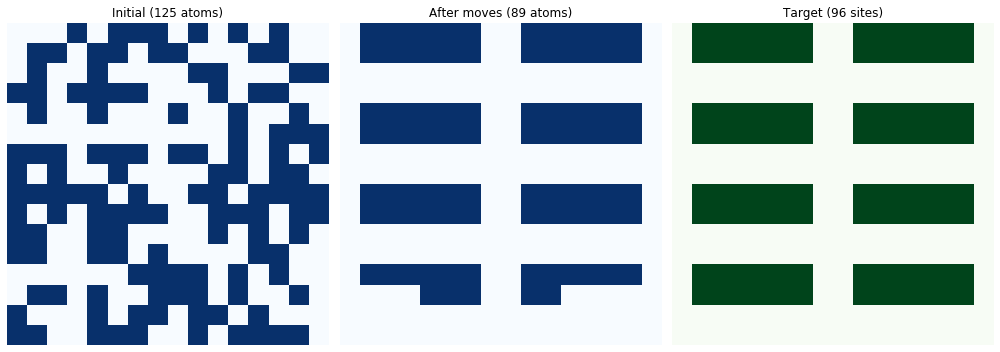

In [24]:
def apply_moves_to_grid(state, moves, grid_rows, grid_cols):
    result = state.copy().astype(bool)
    for move in moves:
        if not move:
            continue
        first, last = move[0], move[-1]
        moving = []
        for ri, r0 in enumerate(first["rows"]):
            for ci, c0 in enumerate(first["cols"]):
                if 0 <= r0 < grid_rows and 0 <= c0 < grid_cols and result[r0, c0]:
                    moving.append((ri, ci))
                    result[r0, c0] = False
        for ri, ci in moving:
            if ri < len(last["rows"]) and ci < len(last["cols"]):
                rN, cN = last["rows"][ri], last["cols"][ci]
                if 0 <= rN < grid_rows and 0 <= cN < grid_cols:
                    result[rN, cN] = True
    return result

sorted_grid = apply_moves_to_grid(state_grid, all_moves, GRID_R, GRID_C)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(state_grid,  cmap="Blues",  origin="upper"); axes[0].set_title(f"Initial ({np.sum(state_grid)} atoms)");  axes[0].axis("off")
axes[1].imshow(sorted_grid, cmap="Blues",  origin="upper"); axes[1].set_title(f"After moves ({np.sum(sorted_grid)} atoms)"); axes[1].axis("off")
axes[2].imshow(target_2d,   cmap="Greens", origin="upper"); axes[2].set_title(f"Target ({np.sum(target_2d)} sites)"); axes[2].axis("off")
plt.tight_layout()
plt.savefig("atomflow_result.png", dpi=150, bbox_inches="tight")
plt.show()

# target_2d is zone-local already, so it is NOT sliced.
zone_sorted = sorted_grid[COMP_R0:COMP_R1, COMP_C0:COMP_C1]
zone_target = target_2d.astype(bool)
diff = int(np.sum(zone_sorted != zone_target))
filled = int(np.sum(zone_sorted & zone_target))
print(f"\nHost replay: {filled}/{int(np.sum(zone_target))} target sites filled,"
      f" {diff} cells differ")
print(f"Controller reported: {t_filled}/{t_required}")
if filled != t_filled:
    print("WARNING: host replay disagrees with the controller's own count -- "
          "the move stream does not reproduce the controller's final lattice")
print(f"{'SUCCESS' if diff == 0 else f'WARNING: {diff} cells differ in comp zone'}")

## 11. Interleaved Pipeline Demo

Architecture (b): PS reads moves from FIFO while sorting is **still running**.
Shows lower latency to first move vs. waiting for AP_DONE.

In [39]:
# ── Interleaved Pipeline Demo ───────────────────────────────────────────────
# With tlast=5: each FIFO packet = one 320B move, decoded per-packet with timestamp.
import sys

MOVE_WIRE_SIZE_IL = 320
MAX_STEPS_IL      = 4
STEP_SIZE_IL      = 66
STEPS_OFF_IL      = MAX_STEPS_IL * STEP_SIZE_IL  # 264

def drain_packets(pkt_list, t_ref):
    """Drain complete packets from FIFO. Safe: checks RDFO before RLR.
    Returns True if at least one packet was read."""
    got_any = False
    while fifo.read(FIFO_RDFO) > 0:
        occ = fifo.read(FIFO_RDFO)
        nb  = fifo.read(FIFO_RLR)
        if nb == 0 or (nb + 3) // 4 > occ:
            break
        raw = bytearray(fifo_read_words((nb + 3) // 4))
        pkt_list.append((bytes(raw), time.perf_counter() - t_ref))
        got_any = True
    return got_any

print("=== Interleaved Pipeline Demo ==="); sys.stdout.flush()

# ── 1. reset FIFO ──────────────────────────────────────────────────────────
fifo.write(FIFO_RDFR, 0xA5)
time.sleep(0.05)

# ── 2. write registers ─────────────────────────────────────────────────────
ctrl.write(MODE_OFFSET, MODE_INITIALIZATION)
write_float(ctrl, THRESHOLD_OFFSET, EMISSION_THRESHOLD)
ctrl.write(ATOM_LOC_SIZE, atom_count)
ctrl.write(PROJ_SHAPE0, proj_shape0); ctrl.write(PROJ_SHAPE1, proj_shape1)
write_addr64(ctrl, ADDR_ATOM_LOC_LO,       ADDR_ATOM_LOC_HI,       atomLocations_buf.physical_address)
ctrl.write(PSF_SUPER, psf_super); ctrl.write(IMG_PROJ_SIZE, img_proj_sz)
write_addr64(ctrl, ADDR_PROJS_LOCAL_LO,    ADDR_PROJS_LOCAL_HI,    imageProjs_local_buf.physical_address)
write_addr64(ctrl, ADDR_IMAGE_PROJS_LO,    ADDR_IMAGE_PROJS_HI,    imageProjs_buf.physical_address)
write_addr64(ctrl, ADDR_PROJS_LOCAL_SZ_LO, ADDR_PROJS_LOCAL_SZ_HI, imageProjs_local_size_buf.physical_address)
write_addr64(ctrl, ADDR_FULL_IMAGE_LO,     ADDR_FULL_IMAGE_HI,     fullImage_buf.physical_address)
ctrl.write(FULL_IMG_ROWS, full_rows); ctrl.write(FULL_IMG_COLS, full_cols)
write_addr64(ctrl, ADDR_EMISSIONS_LO,      ADDR_EMISSIONS_HI,      emissions_buf.physical_address)
ctrl.write(GRID_ROWS, GRID_R); ctrl.write(GRID_COLS, GRID_C)
write_addr64(ctrl, ADDR_TARGET_GEO_LO,     ADDR_TARGET_GEO_HI,     targetGeometry_buf.physical_address)
ctrl.write(COMP_ROW_START, COMP_R0); ctrl.write(COMP_ROW_END, COMP_R1)
ctrl.write(COMP_COL_START, COMP_C0); ctrl.write(COMP_COL_END, COMP_C1)

# ── 3. wait for IDLE ───────────────────────────────────────────────────────
for _ in range(2000):
    if ctrl.read(CTRL) & AP_IDLE: break
    time.sleep(0.001)

# ── 4. start ───────────────────────────────────────────────────────────────
t_start = time.perf_counter()
ctrl.write(CTRL, AP_START)

il_pkts     = []
t_first_pkt = None

# ── 5. main drain loop ─────────────────────────────────────────────────────
while True:
    if drain_packets(il_pkts, t_start):
        if t_first_pkt is None:
            t_first_pkt = il_pkts[0][1]
            print(f"  First packet at {t_first_pkt*1e3:.1f} ms"); sys.stdout.flush()

    if ctrl.read(CTRL) & AP_DONE:
        drain_packets(il_pkts, t_start)   # final drain, no waiting
        break

    if time.perf_counter() - t_start > 60.0:
        print("Timeout!"); break
    time.sleep(0.0001)

t_total = (time.perf_counter() - t_start) * 1e3
mc      = ctrl.read(MOVE_COUNT_REG)
status     = ctrl.read(STATUS_REG)
t_filled   = ctrl.read(TARGETS_FILLED_REG)
t_required = ctrl.read(TARGETS_REQUIRED_REG)
if status != STATUS_OK:
    print(f"  WARNING status={status} "
          f"({ATOMFLOW_STATUS.get(status, 'UNKNOWN')}) "
          f"targets={t_filled}/{t_required}")
total_b = sum(len(p) for p, _ in il_pkts)
print(f"AP_DONE: {t_total:.1f} ms | pkts={len(il_pkts)} | bytes={total_b}/{mc*MOVE_WIRE_SIZE_IL}")

# ── 6. decode (one move per packet) ────────────────────────────────────────
def _dec(raw):
    if len(raw) < STEPS_OFF_IL + 1: return None
    sc = raw[STEPS_OFF_IL]
    if sc == 0 or sc > MAX_STEPS_IL: return None
    # flags byte sits right after stepsCount (offset 265); MOVE_FLAG_DISCARD
    # says the move sweeps atoms out of the array.
    flags = raw[STEPS_OFF_IL + 1] if len(raw) > STEPS_OFF_IL + 1 else 0
    out = []
    for s in range(sc):
        o = s * STEP_SIZE_IL
        cols = list(struct.unpack_from("<16h", raw, o))
        rows = list(struct.unpack_from("<16h", raw, o + 32))
        nc, nr = raw[o + 64], raw[o + 65]
        out.append({"cols": cols[:nc], "rows": rows[:nr],
                    "flags": flags, "discard": bool(flags & MOVE_FLAG_DISCARD)})
    return out

interleaved_moves = []
move_timestamps   = []
for i, (pkt, ts) in enumerate(il_pkts[:mc]):
    mv = _dec(pkt)
    if mv is None:
        sc_b = pkt[STEPS_OFF_IL] if len(pkt) > STEPS_OFF_IL else -1
        print(f"  Decode failed packet {i} stepsCount={sc_b}")
        continue
    interleaved_moves.append(mv)
    move_timestamps.append(ts)

print(f"\n✓ Decoded {len(interleaved_moves)}/{mc} moves")
if move_timestamps:
    print(f"  First move : {move_timestamps[0]*1e3:.1f} ms")
    print(f"  Timestamps : {[f'{t*1e3:.1f}ms' for t in move_timestamps[:8]]}...")

=== Interleaved Pipeline Demo ===
  First packet at 3.4 ms
AP_DONE: 27.9 ms | pkts=29 | bytes=9280/9280

✓ Decoded 29/29 moves
  First move : 3.4 ms
  Timestamps : ['3.4ms', '4.2ms', '5.0ms', '5.8ms', '6.6ms', '7.4ms', '8.2ms', '9.0ms']...


## 12. Latency Benchmark

Measures per-stage latency for paper figures:
- **Image Analysis** (`reconstruct`): MODE_QUBIT_READOUT AP_START→AP_DONE
- **Sorting** (total + per-move): MODE_INITIALIZATION time − image analysis time
- **First-move latency**: time from AP_START to first FIFO packet (interleaved pipeline)

In [46]:
# ── Raw stream is now directly executable: verify, do NOT clean ─────────────
# Previously this cell deleted steps whose column selection was empty, dropped
# moves that became empty, and shifted every timestamp forward by one move
# (losing the last move). That was papering over two producer-side bugs:
#   * Pass A emitted moves with usedIndices == 0, i.e. no tones on one axis;
#   * a backIdx unsigned underflow injected phantom atoms at column 0.
# Both are fixed in the sorter, so the raw stream should need no post-processing.
# This cell now ASSERTS that instead of silently repairing it.

n_empty_step = sum(1 for mv in interleaved_moves for st in mv
                   if not st["cols"] or not st["rows"])
n_empty_move = sum(1 for mv in interleaved_moves if not mv)
# .get() rather than ["discard"]: re-running only the later cells can leave
# moves in memory that were decoded before the flags byte was parsed.
n_discard    = sum(1 for mv in interleaved_moves if mv and mv[0].get("discard", False))
n_noflag     = sum(1 for mv in interleaved_moves if mv and "discard" not in mv[0])
if n_noflag:
    print(f"NOTE: {n_noflag} move(s) were decoded without the flags byte -- "
          f"re-run the decode cell to refresh them.")

print(f"Raw moves received      : {len(interleaved_moves)}")
print(f"  steps with empty axis : {n_empty_step}   (expected 0)")
print(f"  fully empty moves     : {n_empty_move}   (expected 0)")
print(f"  discard moves (flag)  : {n_discard}")

if n_empty_step or n_empty_move:
    print("\nWARNING: the raw stream still contains no-op moves.")
    print("         Expected none from this bitstream -- if you see this, the")
    print("         loaded .bit predates the move_is_emittable() fix.")

# Timestamps are the FIFO packet arrival times, used as-is. The old code shifted
# them by one move; there is no hardware event justifying that, and the packet
# arrival time is already measured directly.
valid_moves = interleaved_moves
valid_ts    = move_timestamps

print(f"\n\u2713 Using all {len(valid_moves)} raw moves unmodified"
      f" ({len(valid_moves)}/{len(interleaved_moves)} = 100%)")
print(f"\n  {'#':>3}  {'t (ms)':>9}  {'steps':>5}   summary")
print(f"  {'-'*3}  {'-'*9}  {'-'*5}   {'-'*60}")
for i, (mv, ts) in enumerate(zip(valid_moves, valid_ts)):
    tag = " [discard]" if mv[0].get("discard", False) else ""
    print(f"  {i:>3}  {ts*1e3:>9.3f}  {len(mv):>5}{tag}   "
          f"rows={mv[0]['rows']}\u2192{mv[-1]['rows']} | "
          f"cols={mv[0]['cols']}\u2192{mv[-1]['cols']}")

# Keep the old names alive so later cells continue to work.
shifted_moves, shifted_ts = valid_moves, valid_ts
cleaned_moves, cleaned_timestamps = valid_moves, valid_ts



✓ After cleaning: 22 moves (was 29)

    #     t (ms)  steps   summary
  ---  ---------  -----   ------------------------------------------------------------
    0      4.222      2   rows=[0]→[-1] | cols=[3, 5, 6, 7, 9, 11, 13]→[3, 5, 6, 7, 9, 11, 13]
    1      4.986      2   rows=[1]→[-1] | cols=[1, 2, 4, 5, 7, 8, 12, 13]→[1, 2, 4, 5, 7, 8, 12, 13]
    2      5.764      4   rows=[2]→[0] | cols=[1, 4, 9, 10, 14, 15]→[4, 5, 6, 9, 10, 11]
    3      6.530      4   rows=[3]→[0] | cols=[1, 3, 4, 5, 6, 10]→[1, 2, 3, 12, 13, 14]
    4      7.308      4   rows=[3]→[1] | cols=[0, 12, 13]→[5, 6, 9]
    5      8.075      4   rows=[4]→[1] | cols=[1, 4, 8, 11, 14]→[3, 4, 10, 11, 12]
    6     10.377      4   rows=[5]→[1] | cols=[11, 13, 14, 15]→[1, 2, 13, 14]
    7     11.140      4   rows=[6]→[4] | cols=[0, 1, 2, 4, 5, 6, 8, 9, 11, 13, 15]→[1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13]
    8     11.908      4   rows=[7]→[4] | cols=[10]→[14]
    9     12.675      4   rows=[7]→[5] | cols=[0, 2, 5, 11, 13

In [26]:
# ---- Latency Benchmark ----
# With tlast=5: each FIFO packet = one 320B move, timestamp is direct per-packet.
import sys
N_RUNS = 5

MOVE_WIRE_SIZE_BM = 320
MAX_STEPS_BM      = 4
STEP_SIZE_BM      = 66
STEPS_OFF_BM      = MAX_STEPS_BM * STEP_SIZE_BM  # 264

def drain_bm(pkt_list, t_ref):
    """Drain complete packets. Safe: checks RDFO before RLR."""
    t_first = None
    while fifo.read(FIFO_RDFO) > 0:
        occ = fifo.read(FIFO_RDFO)
        nb  = fifo.read(FIFO_RLR)
        if nb == 0 or (nb + 3) // 4 > occ:
            break
        raw = bytearray(fifo_read_words((nb + 3) // 4))
        t_now = time.perf_counter() - t_ref
        pkt_list.append((bytes(raw), t_now))
        if t_first is None:
            t_first = t_now
    return t_first

def decode_bm(raw):
    if len(raw) < STEPS_OFF_BM + 1: return None
    sc = raw[STEPS_OFF_BM]
    if sc == 0 or sc > MAX_STEPS_BM: return None
    return sc

t_recon_list    = []
t_total_list    = []
t_first_list    = []
t_last_list     = []
move_ts_all     = []
move_count_list = []

for run in range(N_RUNS):
    # --- 1) Image Analysis only (MODE_QUBIT_READOUT) ---
    for _ in range(10000):
        if ctrl.read(CTRL) & AP_IDLE: break
        time.sleep(0.001)
    ctrl.write(MODE_OFFSET, MODE_QUBIT_READOUT)
    write_float(ctrl, THRESHOLD_OFFSET, 0.0)
    ctrl.write(ATOM_LOC_SIZE, atom_count)
    ctrl.write(PROJ_SHAPE0, proj_shape0); ctrl.write(PROJ_SHAPE1, proj_shape1)
    write_addr64(ctrl, ADDR_ATOM_LOC_LO, ADDR_ATOM_LOC_HI, atomLocations_buf.physical_address)
    ctrl.write(PSF_SUPER, psf_super); ctrl.write(IMG_PROJ_SIZE, img_proj_sz)
    write_addr64(ctrl, ADDR_PROJS_LOCAL_LO, ADDR_PROJS_LOCAL_HI, imageProjs_local_buf.physical_address)
    write_addr64(ctrl, ADDR_IMAGE_PROJS_LO, ADDR_IMAGE_PROJS_HI, imageProjs_buf.physical_address)
    write_addr64(ctrl, ADDR_PROJS_LOCAL_SZ_LO, ADDR_PROJS_LOCAL_SZ_HI, imageProjs_local_size_buf.physical_address)
    write_addr64(ctrl, ADDR_FULL_IMAGE_LO, ADDR_FULL_IMAGE_HI, fullImage_buf.physical_address)
    ctrl.write(FULL_IMG_ROWS, full_rows); ctrl.write(FULL_IMG_COLS, full_cols)
    write_addr64(ctrl, ADDR_EMISSIONS_LO, ADDR_EMISSIONS_HI, emissions_buf.physical_address)
    ctrl.write(GRID_ROWS, GRID_R); ctrl.write(GRID_COLS, GRID_C)
    write_addr64(ctrl, ADDR_TARGET_GEO_LO, ADDR_TARGET_GEO_HI, targetGeometry_buf.physical_address)
    ctrl.write(COMP_ROW_START, COMP_R0); ctrl.write(COMP_ROW_END, COMP_R1)
    ctrl.write(COMP_COL_START, COMP_C0); ctrl.write(COMP_COL_END, COMP_C1)

    t0_recon = time.perf_counter()
    ctrl.write(CTRL, AP_START)
    while not (ctrl.read(CTRL) & AP_DONE):
        time.sleep(0.0001)
    t_recon = (time.perf_counter() - t0_recon) * 1e3
    t_recon_list.append(t_recon)

    # --- 2) Full pipeline (MODE_INITIALIZATION) ---
    fifo.write(FIFO_RDFR, 0xA5)
    time.sleep(0.01)

    for _ in range(10000):
        if ctrl.read(CTRL) & AP_IDLE: break
        time.sleep(0.001)
    ctrl.write(MODE_OFFSET, MODE_INITIALIZATION)
    write_float(ctrl, THRESHOLD_OFFSET, EMISSION_THRESHOLD)
    ctrl.write(ATOM_LOC_SIZE, atom_count)
    ctrl.write(PROJ_SHAPE0, proj_shape0); ctrl.write(PROJ_SHAPE1, proj_shape1)
    write_addr64(ctrl, ADDR_ATOM_LOC_LO, ADDR_ATOM_LOC_HI, atomLocations_buf.physical_address)
    ctrl.write(PSF_SUPER, psf_super); ctrl.write(IMG_PROJ_SIZE, img_proj_sz)
    write_addr64(ctrl, ADDR_PROJS_LOCAL_LO, ADDR_PROJS_LOCAL_HI, imageProjs_local_buf.physical_address)
    write_addr64(ctrl, ADDR_IMAGE_PROJS_LO, ADDR_IMAGE_PROJS_HI, imageProjs_buf.physical_address)
    write_addr64(ctrl, ADDR_PROJS_LOCAL_SZ_LO, ADDR_PROJS_LOCAL_SZ_HI, imageProjs_local_size_buf.physical_address)
    write_addr64(ctrl, ADDR_FULL_IMAGE_LO, ADDR_FULL_IMAGE_HI, fullImage_buf.physical_address)
    ctrl.write(FULL_IMG_ROWS, full_rows); ctrl.write(FULL_IMG_COLS, full_cols)
    write_addr64(ctrl, ADDR_EMISSIONS_LO, ADDR_EMISSIONS_HI, emissions_buf.physical_address)
    ctrl.write(GRID_ROWS, GRID_R); ctrl.write(GRID_COLS, GRID_C)
    write_addr64(ctrl, ADDR_TARGET_GEO_LO, ADDR_TARGET_GEO_HI, targetGeometry_buf.physical_address)
    ctrl.write(COMP_ROW_START, COMP_R0); ctrl.write(COMP_ROW_END, COMP_R1)
    ctrl.write(COMP_COL_START, COMP_C0); ctrl.write(COMP_COL_END, COMP_C1)

    bm_pkts     = []
    t_first_pkt = None

    t0_init = time.perf_counter()
    ctrl.write(CTRL, AP_START)

    while True:
        r = drain_bm(bm_pkts, t0_init)
        if r is not None and t_first_pkt is None:
            t_first_pkt = r

        if ctrl.read(CTRL) & AP_DONE:
            drain_bm(bm_pkts, t0_init)   # final drain, no waiting
            break

        if time.perf_counter() - t0_init > 60.0:
            print(f'Run {run}: TIMEOUT'); break
        time.sleep(0.0001)

    t_total = (time.perf_counter() - t0_init) * 1e3
    mc = ctrl.read(MOVE_COUNT_REG)
    status     = ctrl.read(STATUS_REG)
    t_filled   = ctrl.read(TARGETS_FILLED_REG)
    t_required = ctrl.read(TARGETS_REQUIRED_REG)
    if status != STATUS_OK:
        print(f"  WARNING status={status} ({ATOMFLOW_STATUS.get(status, chr(63))}) targets={t_filled}/{t_required}")
    # Each packet is exactly one move; timestamps come directly from drain_bm.
    move_ts = []
    decoded = 0
    for i, (pkt, ts) in enumerate(bm_pkts[:mc]):
        if decode_bm(pkt) is not None:
            decoded += 1
        move_ts.append(ts * 1e3)

    t_total_list.append(t_total)
    t_first_list.append(t_first_pkt * 1e3 if t_first_pkt is not None else float('nan'))
    t_last_list.append(move_ts[-1] if move_ts else float('nan'))
    move_count_list.append(mc)
    if len(move_ts) > len(move_ts_all):
        move_ts_all = move_ts

    print(f'Run {run}: T_recon={t_recon:.1f}ms  T_total={t_total:.1f}ms  '
          f'T_first={t_first_list[-1]:.1f}ms  decoded={decoded}/{mc}')
    sys.stdout.flush()

# --- Summary ---
t_recon_mean = np.mean(t_recon_list)
t_recon_std  = np.std(t_recon_list)
t_total_mean = np.mean(t_total_list)
t_total_std  = np.std(t_total_list)
t_sort_mean  = t_total_mean - t_recon_mean
t_first_mean = np.nanmean(t_first_list)

if len(move_ts_all) > 1:
    t_per_move = float(np.mean(np.diff(move_ts_all)))
else:
    t_per_move = float('nan')

print(f'\n{"="*50}')
print(f'Latency Breakdown ({N_RUNS} runs, 16x16 grid):')
print(f'{"="*50}')
print(f'  Image Analysis:     {t_recon_mean:7.1f} +/- {t_recon_std:.1f} ms')
print(f'  Sorting (total):    {t_sort_mean:7.1f} ms  (= T_total - T_recon)')
print(f'  Total (AP_DONE):    {t_total_mean:7.1f} +/- {t_total_std:.1f} ms')
print(f'  First move latency: {t_first_mean:7.1f} ms')
print(f'  Per-move interval:  {t_per_move:7.2f} ms  (avg from packet timestamps)')
print(f'  Move count:         {move_count_list[-1]}')
print(f'{"="*50}')

Run 0: T_recon=2.4ms  T_total=25.6ms  T_first=3.2ms  decoded=29/29
Run 1: T_recon=2.4ms  T_total=25.0ms  T_first=3.2ms  decoded=29/29
Run 2: T_recon=2.4ms  T_total=25.1ms  T_first=3.2ms  decoded=29/29
Run 3: T_recon=2.4ms  T_total=25.9ms  T_first=3.2ms  decoded=29/29
Run 4: T_recon=2.4ms  T_total=24.9ms  T_first=3.2ms  decoded=29/29

Latency Breakdown (5 runs, 16x16 grid):
  Image Analysis:         2.4 +/- 0.0 ms
  Sorting (total):       22.9 ms  (= T_total - T_recon)
  Total (AP_DONE):       25.3 +/- 0.4 ms
  First move latency:     3.2 ms
  Per-move interval:     0.80 ms  (avg from packet timestamps)
  Move count:         29


In [ ]:
# ---- Stacked Bar Chart for Paper ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: stacked bar — total latency breakdown
ax = axes[0]
bars = ax.barh(['AtomFlow\nController'], [t_recon_mean], color='#4C72B0', label='Image Analysis')
ax.barh(['AtomFlow\nController'], [t_sort_mean], left=[t_recon_mean], color='#DD8452', label='Sorting')
ax.set_xlabel('Latency (ms)')
ax.set_title('End-to-End Latency Breakdown')
ax.legend(loc='lower right')
ax.set_xlim(0, t_total_mean * 1.15)
# Add text labels on bars
ax.text(t_recon_mean / 2, 0, f'{t_recon_mean:.1f} ms', ha='center', va='center', color='white', fontweight='bold')
ax.text(t_recon_mean + t_sort_mean / 2, 0, f'{t_sort_mean:.1f} ms', ha='center', va='center', color='white', fontweight='bold')

# Right: timeline — per-move arrival (interleaved pipeline)
ax2 = axes[1]
if move_ts_all:
    ax2.scatter(move_ts_all, range(len(move_ts_all)), s=15, c='#55A868', zorder=3)
    ax2.axvline(t_recon_mean, color='#4C72B0', ls='--', lw=1.5, label=f'Image Analysis done ({t_recon_mean:.0f} ms)')
    ax2.set_xlabel('Time since AP_START (ms)')
    ax2.set_ylabel('Move index')
    ax2.set_title('Move Arrival Timeline (Interleaved)')
    ax2.legend(fontsize=8)
    ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('latency_breakdown.pdf', bbox_inches='tight', dpi=150)
plt.savefig('latency_breakdown.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: latency_breakdown.pdf, latency_breakdown.png')

In [44]:
# ---- Latency Benchmark (raw stream, no host-side cleaning) ----
import sys
N_RUNS = 5

MOVE_WIRE_SIZE_BM = 320
MAX_STEPS_BM      = 4
STEP_SIZE_BM      = 66
STEPS_OFF_BM      = MAX_STEPS_BM * STEP_SIZE_BM   # 264
MAX_SEL_BM        = 16

def drain_bm(pkt_list, t_ref):
    t_first = None
    while fifo.read(FIFO_RDFO) > 0:
        occ = fifo.read(FIFO_RDFO)
        nb  = fifo.read(FIFO_RLR)
        if nb == 0 or (nb + 3) // 4 > occ:
            break
        raw = bytearray(fifo_read_words((nb + 3) // 4))
        t_now = time.perf_counter() - t_ref
        pkt_list.append((bytes(raw), t_now))
        if t_first is None:
            t_first = t_now
    return t_first

def decode_full_bm(raw):
    """Return list[step] or None.  step = {'cols': [...], 'rows': [...]}"""
    if len(raw) < STEPS_OFF_BM + 1: return None
    sc = raw[STEPS_OFF_BM]
    if sc == 0 or sc > MAX_STEPS_BM: return None
    flags = raw[STEPS_OFF_BM + 1] if len(raw) > STEPS_OFF_BM + 1 else 0
    out = []
    for s in range(sc):
        o = s * STEP_SIZE_BM
        cols = list(struct.unpack_from(f"<{MAX_SEL_BM}h", raw, o))
        rows = list(struct.unpack_from(f"<{MAX_SEL_BM}h", raw, o + 32))
        nc, nr = raw[o + 64], raw[o + 65]
        if nc > MAX_SEL_BM or nr > MAX_SEL_BM: return None
        out.append({"cols": cols[:nc], "rows": rows[:nr],
                    "flags": flags, "discard": bool(flags & MOVE_FLAG_DISCARD)})
    return out

def clean_and_shift(decoded_moves, raw_ts):
    """Pass-through with a check. Formerly this dropped steps whose column
    selection was empty, dropped moves left empty, and shifted every timestamp
    forward by one (losing the last move). All three were workarounds for
    producer-side bugs that are now fixed in the sorter, so the raw stream is
    directly executable and must be used unmodified.

    The timestamp shift in particular had no hardware event behind it: the FIFO
    packet arrival time is measured directly, so shifting it only corrupted the
    per-move timing it was meant to report.

    Returns (moves, timestamps) unchanged, and warns if the old cleaning would
    still have removed anything -- that would mean the loaded bitstream predates
    the move_is_emittable() fix.
    """
    n_empty = sum(1 for mv in decoded_moves for st in mv if not st["cols"] or not st["rows"])
    if n_empty:
        print(f"  WARNING: {n_empty} step(s) have an empty selection -- the loaded "
              f".bit predates the sorter fix; raw stream is NOT directly executable")
    return decoded_moves, raw_ts


t_recon_list      = []
t_total_list      = []
t_first_list      = []
t_last_list       = []
move_ts_all       = []           # timestamps from longest run
mc_raw_list       = []           # raw move counts (HW reg)
mc_clean_list     = []           # move counts (should equal raw)

for run in range(N_RUNS):
    # --- 1) Image Analysis only (MODE_QUBIT_READOUT) ---
    for _ in range(10000):
        if ctrl.read(CTRL) & AP_IDLE: break
        time.sleep(0.001)
    ctrl.write(MODE_OFFSET, MODE_QUBIT_READOUT)
    write_float(ctrl, THRESHOLD_OFFSET, 0.0)
    ctrl.write(ATOM_LOC_SIZE, atom_count)
    ctrl.write(PROJ_SHAPE0, proj_shape0); ctrl.write(PROJ_SHAPE1, proj_shape1)
    write_addr64(ctrl, ADDR_ATOM_LOC_LO, ADDR_ATOM_LOC_HI, atomLocations_buf.physical_address)
    ctrl.write(PSF_SUPER, psf_super); ctrl.write(IMG_PROJ_SIZE, img_proj_sz)
    write_addr64(ctrl, ADDR_PROJS_LOCAL_LO, ADDR_PROJS_LOCAL_HI, imageProjs_local_buf.physical_address)
    write_addr64(ctrl, ADDR_IMAGE_PROJS_LO, ADDR_IMAGE_PROJS_HI, imageProjs_buf.physical_address)
    write_addr64(ctrl, ADDR_PROJS_LOCAL_SZ_LO, ADDR_PROJS_LOCAL_SZ_HI, imageProjs_local_size_buf.physical_address)
    write_addr64(ctrl, ADDR_FULL_IMAGE_LO, ADDR_FULL_IMAGE_HI, fullImage_buf.physical_address)
    ctrl.write(FULL_IMG_ROWS, full_rows); ctrl.write(FULL_IMG_COLS, full_cols)
    write_addr64(ctrl, ADDR_EMISSIONS_LO, ADDR_EMISSIONS_HI, emissions_buf.physical_address)
    ctrl.write(GRID_ROWS, GRID_R); ctrl.write(GRID_COLS, GRID_C)
    write_addr64(ctrl, ADDR_TARGET_GEO_LO, ADDR_TARGET_GEO_HI, targetGeometry_buf.physical_address)
    ctrl.write(COMP_ROW_START, COMP_R0); ctrl.write(COMP_ROW_END, COMP_R1)
    ctrl.write(COMP_COL_START, COMP_C0); ctrl.write(COMP_COL_END, COMP_C1)

    t0_recon = time.perf_counter()
    ctrl.write(CTRL, AP_START)
    while not (ctrl.read(CTRL) & AP_DONE):
        time.sleep(0.0001)
    t_recon = (time.perf_counter() - t0_recon) * 1e3
    t_recon_list.append(t_recon)

    # --- 2) Full pipeline (MODE_INITIALIZATION) ---
    fifo.write(FIFO_RDFR, 0xA5)
    time.sleep(0.01)

    for _ in range(10000):
        if ctrl.read(CTRL) & AP_IDLE: break
        time.sleep(0.001)
    ctrl.write(MODE_OFFSET, MODE_INITIALIZATION)
    write_float(ctrl, THRESHOLD_OFFSET, EMISSION_THRESHOLD)
    ctrl.write(ATOM_LOC_SIZE, atom_count)
    ctrl.write(PROJ_SHAPE0, proj_shape0); ctrl.write(PROJ_SHAPE1, proj_shape1)
    write_addr64(ctrl, ADDR_ATOM_LOC_LO, ADDR_ATOM_LOC_HI, atomLocations_buf.physical_address)
    ctrl.write(PSF_SUPER, psf_super); ctrl.write(IMG_PROJ_SIZE, img_proj_sz)
    write_addr64(ctrl, ADDR_PROJS_LOCAL_LO, ADDR_PROJS_LOCAL_HI, imageProjs_local_buf.physical_address)
    write_addr64(ctrl, ADDR_IMAGE_PROJS_LO, ADDR_IMAGE_PROJS_HI, imageProjs_buf.physical_address)
    write_addr64(ctrl, ADDR_PROJS_LOCAL_SZ_LO, ADDR_PROJS_LOCAL_SZ_HI, imageProjs_local_size_buf.physical_address)
    write_addr64(ctrl, ADDR_FULL_IMAGE_LO, ADDR_FULL_IMAGE_HI, fullImage_buf.physical_address)
    ctrl.write(FULL_IMG_ROWS, full_rows); ctrl.write(FULL_IMG_COLS, full_cols)
    write_addr64(ctrl, ADDR_EMISSIONS_LO, ADDR_EMISSIONS_HI, emissions_buf.physical_address)
    ctrl.write(GRID_ROWS, GRID_R); ctrl.write(GRID_COLS, GRID_C)
    write_addr64(ctrl, ADDR_TARGET_GEO_LO, ADDR_TARGET_GEO_HI, targetGeometry_buf.physical_address)
    ctrl.write(COMP_ROW_START, COMP_R0); ctrl.write(COMP_ROW_END, COMP_R1)
    ctrl.write(COMP_COL_START, COMP_C0); ctrl.write(COMP_COL_END, COMP_C1)

    bm_pkts     = []
    t_first_pkt = None

    t0_init = time.perf_counter()
    ctrl.write(CTRL, AP_START)

    while True:
        r = drain_bm(bm_pkts, t0_init)
        if r is not None and t_first_pkt is None:
            t_first_pkt = r
        if ctrl.read(CTRL) & AP_DONE:
            drain_bm(bm_pkts, t0_init)
            break
        if time.perf_counter() - t0_init > 60.0:
            print(f'Run {run}: TIMEOUT'); break
        time.sleep(0.0001)

    t_total = (time.perf_counter() - t0_init) * 1e3
    mc_raw  = ctrl.read(MOVE_COUNT_REG)
    status     = ctrl.read(STATUS_REG)
    t_filled   = ctrl.read(TARGETS_FILLED_REG)
    t_required = ctrl.read(TARGETS_REQUIRED_REG)
    if status != STATUS_OK:
        print(f"  WARNING status={status} "
              f"({ATOMFLOW_STATUS.get(status, 'UNKNOWN')}) "
              f"targets={t_filled}/{t_required}")
    # Decode all packets; the raw stream needs no post-processing
    raw_decoded = []
    raw_ts      = []
    for pkt, ts in bm_pkts[:mc_raw]:
        mv = decode_full_bm(pkt)
        if mv is not None:
            raw_decoded.append(mv)
            raw_ts.append(ts * 1e3)        # → ms

    cleaned_moves, cleaned_ts = clean_and_shift(raw_decoded, raw_ts)
    mc_clean = len(cleaned_moves)

    t_first_clean = cleaned_ts[0]  if cleaned_ts else float('nan')
    t_last_clean  = cleaned_ts[-1] if cleaned_ts else float('nan')

    t_total_list.append(t_total)
    t_first_list.append(t_first_clean)
    t_last_list.append(t_last_clean)
    mc_raw_list.append(mc_raw)
    mc_clean_list.append(mc_clean)
    if len(cleaned_ts) > len(move_ts_all):
        move_ts_all = cleaned_ts

    print(f'Run {run}: T_recon={t_recon:6.1f}ms  T_total={t_total:7.1f}ms  '
          f'T_first={t_first_clean:7.1f}ms  '
          f'moves={mc_clean}/{mc_raw}')
    sys.stdout.flush()

# --- Summary ---
t_recon_mean = np.mean(t_recon_list)
t_recon_std  = np.std(t_recon_list)
t_total_mean = np.mean(t_total_list)
t_total_std  = np.std(t_total_list)
t_sort_mean  = t_total_mean - t_recon_mean
t_first_mean = np.nanmean(t_first_list)
t_last_mean  = np.nanmean(t_last_list)
mc_raw_mean   = np.mean(mc_raw_list)
mc_clean_mean = np.mean(mc_clean_list)

if len(move_ts_all) > 1:
    t_per_move = float(np.mean(np.diff(move_ts_all)))
else:
    t_per_move = float('nan')

print(f'\n{"="*60}')
print(f'Latency Breakdown ({N_RUNS} runs, 16x16 grid)  [raw movelist, unmodified]')
print(f'{"="*60}')
print(f'  Image Analysis:        {t_recon_mean:7.1f} +/- {t_recon_std:.1f} ms')
print(f'  Sorting (total):       {t_sort_mean:7.1f} ms  (= T_total - T_recon)')
print(f'  Total (AP_DONE):       {t_total_mean:7.1f} +/- {t_total_std:.1f} ms')
print(f'  First move:            {t_first_mean:7.1f} ms')
print(f'  Last  move:            {t_last_mean:7.1f} ms')
print(f'  Per-move interval:     {t_per_move:7.2f} ms  (avg of cleaned diffs)')
print(f'  Move count raw  / hw:  {mc_raw_mean:7.1f}')
print(f'  Move count used:       {mc_clean_mean:7.1f}  ({mc_clean_mean/mc_raw_mean*100:.0f}% of raw)')
print(f'{"="*60}')


Run 0: T_recon=   2.4ms  T_total=   25.9ms  T_first(clean)=    4.1ms  moves=22/29
Run 1: T_recon=   2.4ms  T_total=   25.1ms  T_first(clean)=    4.0ms  moves=22/29
Run 2: T_recon=   2.4ms  T_total=   25.4ms  T_first(clean)=    4.0ms  moves=22/29
Run 3: T_recon=   2.4ms  T_total=   25.4ms  T_first(clean)=    4.0ms  moves=22/29
Run 4: T_recon=   2.4ms  T_total=   25.4ms  T_first(clean)=    4.0ms  moves=22/29

Latency Breakdown (5 runs, 16x16 grid)  [cleaned movelist]
  Image Analysis:            2.4 +/- 0.0 ms
  Sorting (total):          23.1 ms  (= T_total - T_recon)
  Total (AP_DONE):          25.4 +/- 0.2 ms
  First move (clean):        4.0 ms
  Last  move (clean):       25.4 ms
  Per-move interval:        1.04 ms  (avg of cleaned diffs)
  Move count raw  / hw:     29.0
  Move count cleaned:       22.0  (76% kept)


## 14. Diagnostic — is the 0.78 ms/move interval the sorter or the PS?

Board runs show a **1.3 % coefficient of variation** on the inter-move interval
(0.765-0.805 ms) even though the moves differ a lot in work (1-12 tones, 2-4
steps). Meanwhile the HLS report combined with measured C-simulation iteration
counts bounds the whole sorter at about **1.74 ms**, not 22 ms.

Hypothesis: the interval is the **PS draining the FIFO**, not the sorter.
Each 320 B packet needs 80 individual 32-bit `MMIO.read()` calls, and
0.7745 ms / 83 reads = 9.3 us per read, which is the normal cost of a PYNQ
Python MMIO access.

The three tests below decide it. None of them changes the bitstream or the
sorter; A and C do not even start the kernel.

In [ ]:
# ── A. How long does one MMIO read actually take? ──────────────────────────
import time, statistics

N = 20000
t0 = time.perf_counter()
for _ in range(N):
    fifo.read(FIFO_RDFO)
t_mmio_us = (time.perf_counter() - t0) * 1e6 / N
print(f"A. single MMIO read            : {t_mmio_us:6.2f} us")
print(f"   -> 83 reads (one 320B packet): {t_mmio_us*83/1000:6.3f} ms")
print(f"   board inter-move interval    :  0.7745 ms")
print(f"   {'MATCHES -> PS-bound' if abs(t_mmio_us*83/1000 - 0.7745) < 0.25 else 'does NOT match -> look elsewhere'}")

# ── B. Arrival times WITHOUT draining the data ─────────────────────────────
# Poll only the occupancy register (1 read) instead of pulling 80 data words.
# The FIFO holds 512 words = 6.4 packets, so the sorter stalls once it is full;
# the packets that arrive before that are at pure hardware rate.
print("\nB. arrival times while polling occupancy only (no data reads)")

def program_init():
    fifo.write(FIFO_RDFR, 0xA5); time.sleep(0.05)
    ctrl.write(MODE_OFFSET, MODE_INITIALIZATION)
    write_float(ctrl, THRESHOLD_OFFSET, EMISSION_THRESHOLD)
    ctrl.write(ATOM_LOC_SIZE, atom_count)
    ctrl.write(PROJ_SHAPE0, proj_shape0); ctrl.write(PROJ_SHAPE1, proj_shape1)
    write_addr64(ctrl, ADDR_ATOM_LOC_LO, ADDR_ATOM_LOC_HI, atomLocations_buf.physical_address)
    ctrl.write(PSF_SUPER, psf_super); ctrl.write(IMG_PROJ_SIZE, img_proj_sz)
    write_addr64(ctrl, ADDR_PROJS_LOCAL_LO, ADDR_PROJS_LOCAL_HI, imageProjs_local_buf.physical_address)
    write_addr64(ctrl, ADDR_IMAGE_PROJS_LO, ADDR_IMAGE_PROJS_HI, imageProjs_buf.physical_address)
    write_addr64(ctrl, ADDR_PROJS_LOCAL_SZ_LO, ADDR_PROJS_LOCAL_SZ_HI, imageProjs_local_size_buf.physical_address)
    write_addr64(ctrl, ADDR_FULL_IMAGE_LO, ADDR_FULL_IMAGE_HI, fullImage_buf.physical_address)
    ctrl.write(FULL_IMG_ROWS, full_rows); ctrl.write(FULL_IMG_COLS, full_cols)
    write_addr64(ctrl, ADDR_EMISSIONS_LO, ADDR_EMISSIONS_HI, emissions_buf.physical_address)
    ctrl.write(GRID_ROWS, GRID_R); ctrl.write(GRID_COLS, GRID_C)
    write_addr64(ctrl, ADDR_TARGET_GEO_LO, ADDR_TARGET_GEO_HI, targetGeometry_buf.physical_address)
    ctrl.write(COMP_ROW_START, COMP_R0); ctrl.write(COMP_ROW_END, COMP_R1)
    ctrl.write(COMP_COL_START, COMP_C0); ctrl.write(COMP_COL_END, COMP_C1)

WORDS_PER_PKT = MOVE_WIRE_SIZE // 4          # 80
program_init()
while not ctrl.read(CTRL) & AP_IDLE:
    pass

arrivals, seen, occ_prev = [], 0, 0
t0 = time.perf_counter()
ctrl.write(CTRL, AP_START)
while time.perf_counter() - t0 < 3.0:
    occ = fifo.read(FIFO_RDFO)
    if occ != occ_prev:                       # occupancy grew -> new words landed
        occ_prev = occ
        while occ // WORDS_PER_PKT > seen:    # one entry per complete packet
            seen += 1
            arrivals.append((time.perf_counter() - t0) * 1e3)
    if ctrl.read(CTRL) & AP_DONE:
        break
    if len(arrivals) >= 6 and time.perf_counter() - t0 > 1.0:
        break                                 # FIFO is full, sorter has stalled

print(f"   packets observed before the FIFO filled: {len(arrivals)}")
for i, a in enumerate(arrivals):
    gap = f"  (+{a - arrivals[i-1]:.3f} ms)" if i else ""
    print(f"     packet {i}: {a:8.3f} ms{gap}")
if len(arrivals) >= 3:
    gaps = [arrivals[i] - arrivals[i-1] for i in range(1, len(arrivals))]
    m = statistics.mean(gaps)
    print(f"   mean gap = {m:.3f} ms   vs 0.7745 ms when the PS drains data")
    print(f"   -> {'sorter IS the bottleneck' if m > 0.5 else 'PS drain IS the bottleneck (sorter is ~%.0fx faster)' % (0.7745/m)}")

# leave the kernel in a clean state: drain whatever is queued and let it finish
_t = time.perf_counter()
while not (ctrl.read(CTRL) & AP_DONE) and time.perf_counter() - _t < 60:
    while fifo.read(FIFO_RDFO) > 0:
        nb_ = fifo.read(FIFO_RLR)
        if nb_ == 0: break
        fifo_read_words((nb_ + 3) // 4)   # discard
while fifo.read(FIFO_RDFO) > 0:
    fifo_read_words(1)   # discard
print(f"   kernel drained, status = {ctrl.read(STATUS_REG)}")

# ── C. Would a bulk read help? ─────────────────────────────────────────────
print("\nC. per-word loop vs bulk numpy read of 80 words")
try:
    arr = fifo.array                          # uint32 view of the same region
    t0 = time.perf_counter()
    for _ in range(200):
        _ = [fifo.read(FIFO_RDFO) for _ in range(80)]
    t_loop = (time.perf_counter() - t0) * 1e3 / 200
    t0 = time.perf_counter()
    for _ in range(200):
        _ = arr[FIFO_RDFO // 4]
    t_bulk = (time.perf_counter() - t0) * 1e6 / 200
    print(f"   80 x MMIO.read()  : {t_loop:7.3f} ms per packet")
    print(f"   single array read : {t_bulk:7.2f} us")
    print("   NOTE: RDFD is a streaming FIFO port, so a numpy slice cannot replace")
    print("   the reads directly; the comparison only bounds the Python call overhead.")
except AttributeError:
    print("   fifo.array not available in this PYNQ version - skipped")


# ── D. Does the fast reader return the SAME bytes as MMIO.read()? ──────────
# Speed is worthless if it corrupts the stream. Run one INIT, pull the first
# packet through each path, and compare byte for byte.
print("\nD. fifo_read_words() vs MMIO.read() equivalence")
if not _FAST_FIFO:
    print("   numpy view unavailable on this PYNQ - fast path is the fallback, nothing to compare")
else:
    program_init()
    while not ctrl.read(CTRL) & AP_IDLE:
        pass
    ctrl.write(CTRL, AP_START)
    while fifo.read(FIFO_RDFO) < 2 * (MOVE_WIRE_SIZE // 4):
        if ctrl.read(CTRL) & AP_DONE:
            break

    nb1 = fifo.read(FIFO_RLR)
    t0 = time.perf_counter(); pkt_fast = fifo_read_words((nb1 + 3) // 4)
    t_fast = (time.perf_counter() - t0) * 1e3

    nb2 = fifo.read(FIFO_RLR)
    t0 = time.perf_counter()
    pkt_slow = b"".join(struct.pack("<I", fifo.read(FIFO_RDFD)) for _ in range((nb2 + 3) // 4))
    t_slow = (time.perf_counter() - t0) * 1e3

    m_fast, m_slow = decode_move(pkt_fast), decode_move(pkt_slow)
    same_len   = len(pkt_fast) == len(pkt_slow) == MOVE_WIRE_SIZE
    both_ok    = m_fast is not None and m_slow is not None
    print(f"   packet sizes      : {len(pkt_fast)} / {len(pkt_slow)} B  ({'ok' if same_len else 'MISMATCH'})")
    print(f"   both decode       : {'yes' if both_ok else 'NO'}")
    if both_ok:
        print(f"   fast steps={len(m_fast)} rows={m_fast[0]['rows'][:4]} cols={m_fast[0]['cols'][:4]}")
        print(f"   slow steps={len(m_slow)} rows={m_slow[0]['rows'][:4]} cols={m_slow[0]['cols'][:4]}")
        print("   (different moves are expected - these are consecutive packets, not the same one)")
    print(f"   time per packet   : fast {t_fast:.3f} ms   slow {t_slow:.3f} ms"
          f"   speedup {t_slow/t_fast if t_fast else 0:.1f}x")

    _t = time.perf_counter()
    while not (ctrl.read(CTRL) & AP_DONE) and time.perf_counter() - _t < 60:
        while fifo.read(FIFO_RDFO) > 0:
            n_ = fifo.read(FIFO_RLR)
            if n_ == 0: break
            fifo_read_words((n_ + 3) // 4)
    while fifo.read(FIFO_RDFO) > 0:
        fifo_read_words(1)
    print(f"   kernel drained, status = {ctrl.read(STATUS_REG)}")


## 13. Cleanup

In [ ]:
print("Done.")